## Imports

In [82]:
# For data processing, pandas is enough because the dataframe has less than 1M rows
import pandas as pd

# For printing the dataframe in a nice way
from great_tables import GT

# For date and time manipulation
import datetime

# For converting all currencies to US dollars
from forex_python.converter import CurrencyRates

# For data vizualization
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
# Import the financial data got from the API call to process it
financial_data = pd.read_csv("../data/outputs/stock_data.csv")

##### Table definition 
The table financial_data contains stock market data for various companies over a period of time.  
Each row represents the stock data for a specific company on a specific date.  
The included information encompasses stocks prices during the days, traded volumes, dividends associated and currencies. 

In [59]:
# Print the first 10 rows of the imported table
financial_data.head(10)

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,437.920,439.360,421.88,429.52,103471495.0,439.360,421.88,429.52,437.920,103471495.0,1.0,0.0,Tesla Inc,NASDAQ,Stock,USD,TSLA,XNAS,2025-11-07T00:00:00.000000+0000
1,496.945,499.377,493.25,496.82,24019764.0,499.377,493.25,496.82,496.945,24019764.0,1.0,0.0,Microsoft Corporation,NASDAQ,Stock,USD,MSFT,XNAS,2025-11-07T00:00:00.000000+0000
2,184.900,188.320,178.91,188.15,264942255.0,188.320,178.91,188.15,184.900,264942255.0,1.0,0.0,NVIDIA Corp,NASDAQ,Stock,USD,NVDA,XNAS,2025-11-07T00:00:00.000000+0000
3,242.900,244.900,238.49,244.41,46374294.0,244.900,238.49,244.41,242.900,46374294.0,1.0,0.0,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2025-11-07T00:00:00.000000+0000
4,407.000,413.395,406.30,413.26,627142.0,413.395,406.30,413.26,407.000,627142.0,1.0,0.0,Ferrari N.V.,NYSE,Stock,USD,RACE,XNYS,2025-11-07T00:00:00.000000+0000
5,461.960,467.450,435.09,445.91,104867157.0,467.450,435.09,445.91,461.960,109622907.0,1.0,0.0,Tesla Inc,NASDAQ,Stock,USD,TSLA,XNAS,2025-11-06T00:00:00.000000+0000
6,196.355,197.620,186.38,188.08,219135616.0,197.620,186.38,188.08,196.420,223029778.0,1.0,0.0,NVIDIA Corp,NASDAQ,Stock,USD,NVDA,XNAS,2025-11-06T00:00:00.000000+0000
7,505.360,505.700,495.81,497.10,27048995.0,505.700,495.81,497.10,505.660,27406496.0,1.0,0.0,Microsoft Corporation,NASDAQ,Stock,USD,MSFT,XNAS,2025-11-06T00:00:00.000000+0000
8,249.220,250.380,242.17,243.04,43139744.0,250.380,242.17,243.04,249.155,46004203.0,1.0,0.0,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2025-11-06T00:00:00.000000+0000
9,407.670,409.300,402.51,405.62,818743.0,409.300,402.51,405.62,407.670,828242.0,1.0,0.0,Race Eco Chain Limited,NaN,Stock,INR,RACE,XNYS,2025-11-06T00:00:00.000000+0000


## Test great-tables display  

In [60]:
# Test the great-tables library only on the first 10 rows to limit output size
gt = GT(financial_data.head(10))

In [61]:
gt

open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
437.92,439.36,421.88,429.52,103471495.0,439.36,421.88,429.52,437.92,103471495.0,1.0,0.0,Tesla Inc,NASDAQ,Stock,USD,TSLA,XNAS,2025-11-07T00:00:00.000000+0000
496.945,499.377,493.25,496.82,24019764.0,499.377,493.25,496.82,496.945,24019764.0,1.0,0.0,Microsoft Corporation,NASDAQ,Stock,USD,MSFT,XNAS,2025-11-07T00:00:00.000000+0000
184.9,188.32,178.91,188.15,264942255.0,188.32,178.91,188.15,184.9,264942255.0,1.0,0.0,NVIDIA Corp,NASDAQ,Stock,USD,NVDA,XNAS,2025-11-07T00:00:00.000000+0000
242.9,244.9,238.49,244.41,46374294.0,244.9,238.49,244.41,242.9,46374294.0,1.0,0.0,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2025-11-07T00:00:00.000000+0000
407.0,413.395,406.3,413.26,627142.0,413.395,406.3,413.26,407.0,627142.0,1.0,0.0,Ferrari N.V.,NYSE,Stock,USD,RACE,XNYS,2025-11-07T00:00:00.000000+0000
461.96,467.45,435.09,445.91,104867157.0,467.45,435.09,445.91,461.96,109622907.0,1.0,0.0,Tesla Inc,NASDAQ,Stock,USD,TSLA,XNAS,2025-11-06T00:00:00.000000+0000
196.355,197.62,186.38,188.08,219135616.0,197.62,186.38,188.08,196.42,223029778.0,1.0,0.0,NVIDIA Corp,NASDAQ,Stock,USD,NVDA,XNAS,2025-11-06T00:00:00.000000+0000
505.36,505.7,495.81,497.1,27048995.0,505.7,495.81,497.1,505.66,27406496.0,1.0,0.0,Microsoft Corporation,NASDAQ,Stock,USD,MSFT,XNAS,2025-11-06T00:00:00.000000+0000
249.22,250.38,242.17,243.04,43139744.0,250.38,242.17,243.04,249.155,46004203.0,1.0,0.0,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2025-11-06T00:00:00.000000+0000
407.67,409.3,402.51,405.62,818743.0,409.3,402.51,405.62,407.67,828242.0,1.0,0.0,Race Eco Chain Limited,,Stock,INR,RACE,XNYS,2025-11-06T00:00:00.000000+0000


## Document the data  

### Columns definitions

In [62]:
financial_data.columns

Index(['open', 'high', 'low', 'close', 'volume', 'adj_high', 'adj_low',
       'adj_close', 'adj_open', 'adj_volume', 'split_factor', 'dividend',
       'name', 'exchange_code', 'asset_type', 'price_currency', 'symbol',
       'exchange', 'date'],
      dtype='object')

##### Columns definitions:
**open:** Opening price of the stock at the start of the day.  
**high:** Highest price reached by the stock during the day.  
**low:** Lowest price reached by the stock during the day.  
**close:** Closing price of the stock at the end of the day.  
**volume:** Total number of shares traded during the day.  
**adj_high:** Highest price adjusted for stock splits or dividends.  
**adj_low:** Lowest price adjusted for stock splits or dividends.  
**adj_close:** Closing price adjusted for stock splits or dividends.  
**adj_open:** Opening price adjusted for stock splits or dividends.  
**adj_volume:** Trading volume adjusted for stock splits.  
**split_factor:** Ratio used to adjust share count and price after a stock split.  
**dividend:** Dividend amount paid per share on that date (if applicable).  
**name:** Full company or asset name associated with the ticker.  
**exchange_code:** Short code identifying the exchange (e.g., NYSE, NASDAQ).  
**asset_type:** Type of financial asset (e.g., stock, ETF, index).  
**price_currency:** Currency in which the price is quoted (e.g., USD, EUR).  
**symbol:** Unique ticker symbol of the asset (e.g., TSLA, RACE).  
**exchange:** Full name of the stock exchange where the asset is listed.  
**date:** Date of the quotation, usually in ISO format with timezone.  

### Table granularity  

In [63]:
## Number of rows in the table
print(f"There are {len(financial_data)} rows in the financial data table.")

## Number of companies in the table
print(f"There are {financial_data['name'].nunique()} unique companies in the financial data table.")

## Number of dates in the table
print(f"There are {financial_data['date'].nunique()} unique dates in the financial data table.")

## Number of combinations dates-companies in the table
print(f"There are {len(financial_data[['date', 'name']].drop_duplicates())} unique combinations of dates and companies names in the financial data table.")

print("The granularity of the data is at the date-company level. Be cautious with companies names that may have changed over time.")

There are 365 rows in the financial data table.
There are 10 unique companies in the financial data table.
There are 73 unique dates in the financial data table.
There are 365 unique combinations of dates and companies names in the financial data table.
The granularity of the data is at the date-company level. Be cautious with companies names that may have changed over time.


### Data types of each column  

In [64]:
# Display the data types of each column
financial_data.dtypes

# Data types seem correct, except for the date column that should be converted to a datetime type

open              float64
high              float64
low               float64
close             float64
volume            float64
adj_high          float64
adj_low           float64
adj_close         float64
adj_open          float64
adj_volume        float64
split_factor      float64
dividend          float64
name               object
exchange_code      object
asset_type         object
price_currency     object
symbol             object
exchange           object
date               object
dtype: object

## Process the data  

### Convert the date column to datetime type using pendulum 

In [65]:
# The native date format of MarketStack API is in UTC timezone
financial_data["utc_time"] = pd.to_datetime(financial_data["date"], utc=True)

# We also need to get a column with the Paris timezone (developer is based in France)
financial_data["france_time"] = financial_data["utc_time"].dt.tz_convert("Europe/Paris")

# Keep only the dates in dates columns as we have 1 row per day only
financial_data["utc_date"] = financial_data["utc_time"].dt.date
financial_data["france_date"] = financial_data["france_time"].dt.date

# Remove the original date column that is not in datetime format
financial_data = financial_data.drop(columns=['date'])

### Clean the column name to have consistent naming convention

In [66]:
# Mapping of company names to unify different namings for the same company
mapping_company_names = {
                            'Tesla Inc': 'Tesla',
                            'Microsoft Corporation': 'Microsoft',
                            'NVIDIA Corp': 'NVIDIA',
                            'Amazon.com Inc': 'Amazon',
                            'Ferrari N.V.': 'Ferrari',
                            'Race Eco Chain Limited': 'Ferrari',
                            'LS 1x Tesla Tracker ETC': 'Tesla',
                            'NVIDIA CORP': 'NVIDIA',
                            '1X MSFT': 'Microsoft',
                            '1X AMZN': 'Amazon'
                        }

# Apply the mapping to the name column
financial_data['name'] = financial_data['name'].map(mapping_company_names).fillna(financial_data['name'])

# Rename the name column
financial_data = financial_data.rename(columns={'name': 'company_name'})

### Keep only the columns that are useful for analysis

In [67]:
# Specify the columns to keep for further analysis
columns_to_keep = [ 
                    # We only keep the French time as it is the developer's local time
                    'france_time', 
                    # We keep the company name to identify each row
                    'company_name',
                    # We keep the opening price to compare it with the closing price
                    'open', 
                    # We keep the closing price to compare it with the opening price
                    'close',
                    # We keep the highest and lowest prices of the day for further analysis
                    'high',
                    'low',
                    # We keep the currency to know in which currency the prices are denominated
                    'price_currency',
                    # We keep the traded volume to compare quantities of stocks traded every day
                    'volume'
                ]

# Keep only the specified columns
financial_data = financial_data[columns_to_keep]

# Print the dataframe after keeping only the specified columns
financial_data.head()

,france_time,company_name,open,close,high,low,price_currency,volume
0,2025-11-07 01:00:00+01:00,Tesla,437.920,429.52,439.360,421.88,USD,103471495.0
1,2025-11-07 01:00:00+01:00,Microsoft,496.945,496.82,499.377,493.25,USD,24019764.0
2,2025-11-07 01:00:00+01:00,NVIDIA,184.900,188.15,188.320,178.91,USD,264942255.0
3,2025-11-07 01:00:00+01:00,Amazon,242.900,244.41,244.900,238.49,USD,46374294.0
4,2025-11-07 01:00:00+01:00,Ferrari,407.000,413.26,413.395,406.30,USD,627142.0


### Convert all prices to US dollars for easier comparison between companies  

In [ ]:
# Create a function that manages currency conversion to US dollars
def convert_to_usd(row, price_column, currency_column, currency_rates) -> str:
    
    # Take the value of the price in the price column
    price = row[price_column]
    # Take the value of the currency in the currency column
    currency = row[currency_column]

    # If the currency is already in USD, return the original price
    if currency=='USD':
        return price
    else:
        # Else, convert the price to USD using forex-python library
        try:
            converted_price = currency_rates.convert(currency, 'USD', price)
            return converted_price
        except:
            # If conversion fails, return None
            return None
        
## Apply the function to the financial_data dataframe to convert all prices to USD
financial_data['open_price_in_usd'] = financial_data.apply(lambda row: convert_to_usd(row,'open', 'price_currency', CurrencyRates()), axis=1)

## EDA

In [81]:
financial_data['price_currency'].value_counts()

price_currency
USD    243
INR     65
ARS     20
EUR     20
GBP     17
Name: count, dtype: int64

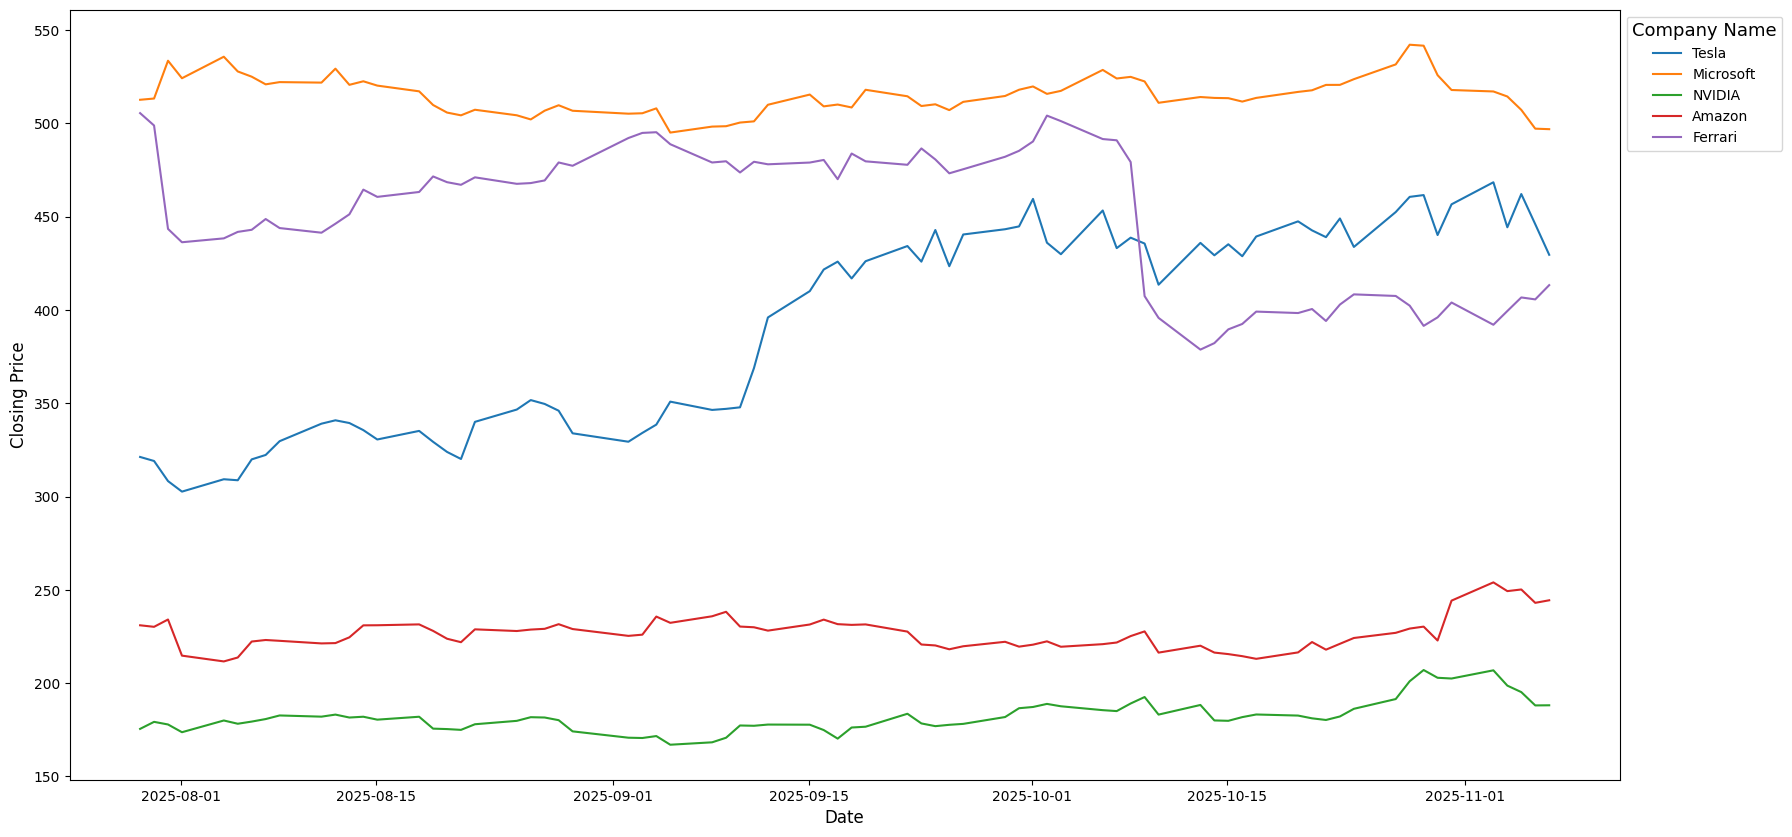

In [ ]:
# Create a chart large enough to display all companies data
plt.figure(figsize=(20, 10))

# Evolution of the closing price over time for each company
ax = sns.lineplot(financial_data, y='close', x='france_time', hue='company_name')

# Change the x-axis and y-axis labels for better readability
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Closing Price in US $", fontsize=12)

# Change the title in the legend to make it cleaner
ax.legend(title='Company Name', title_fontsize='13', fontsize='11')

# Change the legend position to make it more readable
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [79]:
financial_data

,france_time,company_name,open,close,high,low,price_currency,volume
0,2025-11-07 01:00:00+01:00,Tesla,437.920,429.52,439.360,421.88,USD,103471495.0
1,2025-11-07 01:00:00+01:00,Microsoft,496.945,496.82,499.377,493.25,USD,24019764.0
2,2025-11-07 01:00:00+01:00,NVIDIA,184.900,188.15,188.320,178.91,USD,264942255.0
3,2025-11-07 01:00:00+01:00,Amazon,242.900,244.41,244.900,238.49,USD,46374294.0
4,2025-11-07 01:00:00+01:00,Ferrari,407.000,413.26,413.395,406.30,USD,627142.0
...,...,...,...,...,...,...,...,...
360,2025-07-29 02:00:00+02:00,Tesla,325.550,321.20,326.250,318.25,GBP,87136300.0
361,2025-07-29 02:00:00+02:00,Microsoft,515.530,512.57,517.620,511.56,EUR,16444700.0
362,2025-07-29 02:00:00+02:00,Amazon,234.150,231.01,234.720,230.31,EUR,33684300.0
363,2025-07-29 02:00:00+02:00,NVIDIA,177.960,175.51,179.380,175.02,ARS,153716500.0


In [70]:
#Create a column to calculate the variation between opening and closing prices for each day and each company  
financial_data.groupby(['company_name, france_date']).apply(lambda x: x['close'] - x['open'])

KeyError: 'company_name, france_date'

In [ ]:

## Comparison of variations between opening and closing prices for each company

# Correlation between traded volume and price variations for each company

## Highest prices reached during the period for each company

## Lowest prices reached during the period for each company

